<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [2]:
# Because data set was saved with the index, I will specify this on the read_csv
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv', index_col=0)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


Is there a significant difference in the median value of houses bounded by the Charles river or not?

Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

<h1>Final Project:</h1> For the project scenario, here is an overview of your tasks. The following reading sections will provide you with detailed instructions for each task.

<h3>Project Tasks:</h3>

Task 1: Familiarize yourself with the dataset

Task 2: Generate basic statistics and visualizations for upper management.

Task 3: Use the appropriate tests to answer the questions provided.

Task 4: Share your Jupyter Notebook.

* <b>CRIM</b> - per capita crime rate by town
* <b>ZN</b> - proportion of residential land zoned for lots over 25,000 sq.ft.
* <b>INDUS</b> - proportion of non-retail business acres per town.
* <b>CHAS</b> - Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* <b>NOX</b> - nitric oxides concentration (parts per 10 million)
* <b>RM</b> - average number of rooms per dwelling
* <b>AGE</b> - proportion of owner-occupied units built prior to 1940
* <b>DIS</b> - weighted distances to five Boston employment centres
* <b>RAD</b> - index of accessibility to radial highways
* <b>TAX</b> - full-value property-tax rate per \$10,000
* <b>PTRATIO</b> - pupil-teacher ratio by town
* <b>LSTAT</b> - % lower status of the population
* <b>MEDV</b> - Median value of owner-occupied homes in $1000's

In [3]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 55.3 KB


In [4]:
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48,22.0


In [5]:
boston_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


For the "Median value of owner-occupied homes" provide a boxplot

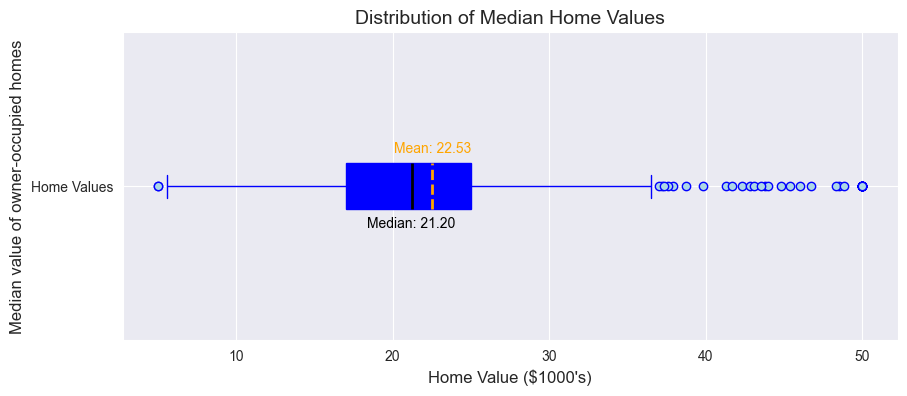

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

box = ax.boxplot(
    boston_df['MEDV'],
    patch_artist=True,
    vert=False,
    showmeans=True,
    meanline=True,
    meanprops={
        'color': 'orange',
        'linewidth': 2
    },
    boxprops={
        'facecolor': 'blue',
        'color': 'blue'
    },
    medianprops={
        'color': 'black',
        'linewidth': 2
    },
    whiskerprops={
        'color': 'blue'
    },
    capprops={
        'color': 'blue'
    },
    flierprops={
        'markerfacecolor': 'lightblue',
        'markeredgecolor': 'blue'
    }
)

ax.set_xlabel("Home Value ($1000's)", fontsize=12)
ax.set_ylabel("Median value of owner-occupied homes", fontsize=12)
ax.set_title("Distribution of Median Home Values", fontsize=14)
ax.set_yticks([1])
ax.set_yticklabels(["Home Values"])
ax.grid(True, axis='x')

mean_val = boston_df['MEDV'].mean()
median_val = boston_df['MEDV'].median()

ax.text(mean_val, 1.1, f'Mean: {mean_val:.2f}', color='orange', ha='center', va='bottom', fontsize=10)
ax.text(median_val, 0.9, f'Median: {median_val:.2f}', color='black', ha='center', va='top', fontsize=10)

plt.show()

Provide a  bar plot for the Charles river variable

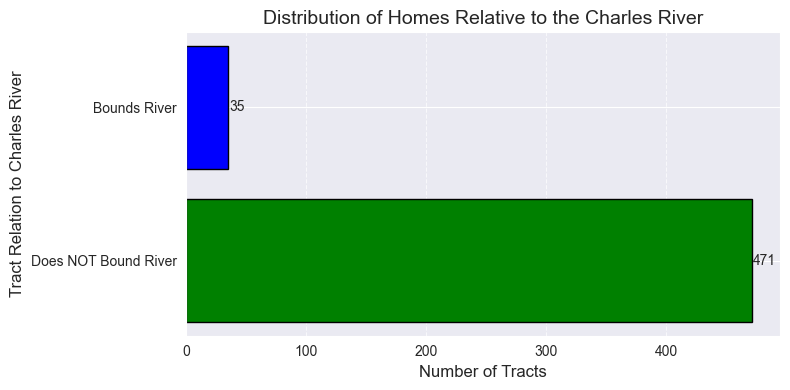

In [7]:
chas_counts = boston_df['CHAS'].value_counts(sort=False)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    ['Does NOT Bound River', 'Bounds River'],
    chas_counts,
    color=['green', 'blue'],
    edgecolor='black'
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        ha='left',
        va='center',
        fontsize=10
    )

ax.set_ylabel('Tract Relation to Charles River', fontsize=12)
ax.set_xlabel('Number of Tracts', fontsize=12)
ax.set_title('Distribution of Homes Relative to the Charles River', fontsize=14)

ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Provide a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

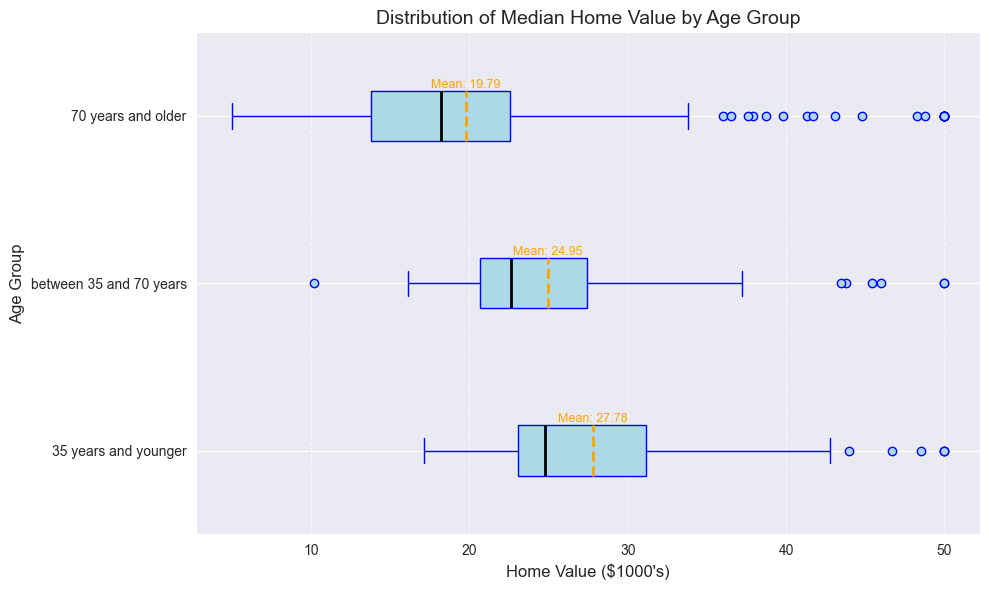

In [12]:
boston_df['age_group'] = pd.cut(
    boston_df['AGE'],
    bins=[0, 35, 70, 100],
    labels=['35 years and younger', 'between 35 and 70 years', '70 years and older']
)

grouped_data = [
    boston_df[boston_df['age_group'] == '35 years and younger']['MEDV'],
    boston_df[boston_df['age_group'] == 'between 35 and 70 years']['MEDV'],
    boston_df[boston_df['age_group'] == '70 years and older']['MEDV']
]

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    grouped_data,
    patch_artist=True,
    vert=False,
    showmeans=True,
    meanline=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='black', linewidth=2),
    meanprops=dict(color='orange', linewidth=2),
    whiskerprops=dict(color='blue'),
    capprops=dict(color='blue'),
    flierprops=dict(markerfacecolor='lightblue', markeredgecolor='blue')
)

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['35 years and younger', 'between 35 and 70 years', '70 years and older'])

ax.set_ylabel('Age Group', fontsize=12)
ax.set_xlabel('Home Value ($1000\'s)', fontsize=12)
ax.set_title('Distribution of Median Home Value by Age Group', fontsize=14)

ax.grid(True, axis='x', linestyle='--', alpha=0.7)

group_means = [
    grouped_data[0].mean(),
    grouped_data[1].mean(),
    grouped_data[2].mean()
]

for i, mean in enumerate(group_means, start=1):
    ax.text(
        mean,
        i + 0.15,
        f'Mean: {mean:.2f}',
        color='orange',
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

State the hypothesis
* $H_0: µ_1 = µ_2 = µ_3$ (the three population means are equal)
* $H_1:$ At least one of the means differ
* <b>AGE</b> - proportion of owner-occupied units built prior to 1940
* <b>MEDV</b> - Median value of owner-occupied homes in $1000's

* <b>Hypothesis:</b> As the AGE increases, the MEDV will decrease.

Provide a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?

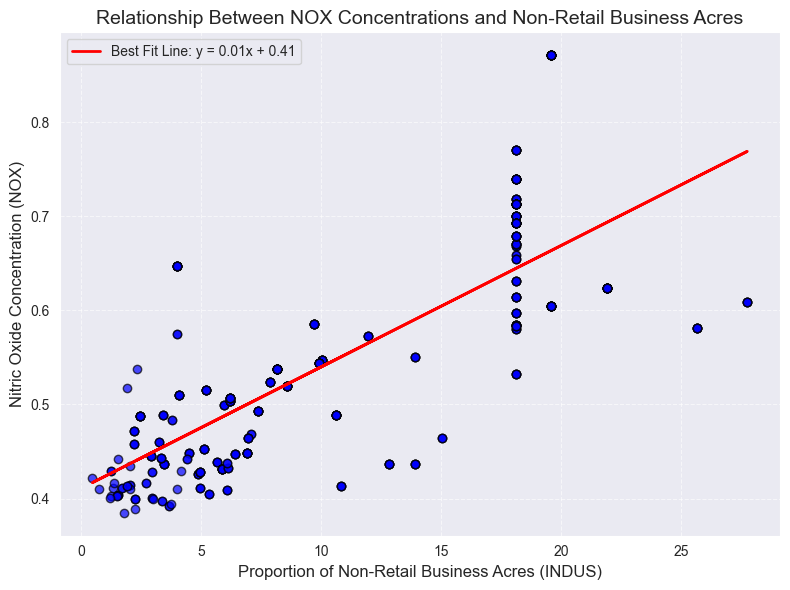

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(boston_df['INDUS'], boston_df['NOX'], color='blue', edgecolor='black', alpha=0.7)

slope, intercept = np.polyfit(boston_df['INDUS'], boston_df['NOX'], 1)
x_vals = np.array(boston_df['INDUS'])
y_vals = slope * x_vals + intercept

plt.plot(x_vals, y_vals, color='red', linewidth=2, label=f'Best Fit Line: y = {slope:.2f}x + {intercept:.2f}')

plt.xlabel('Proportion of Non-Retail Business Acres (INDUS)', fontsize=12)
plt.ylabel('Nitric Oxide Concentration (NOX)', fontsize=12)
plt.title('Relationship Between NOX Concentrations and Non-Retail Business Acres', fontsize=14)

plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

There is an observable vertical clustering of towns at around INDUS = 18, suggesting that multiple towns shared similar zoning policies regarding industrial land usage, even though their actual nitric oxide levels varied independently.

Create a histogram for the pupil to teacher ratio variable

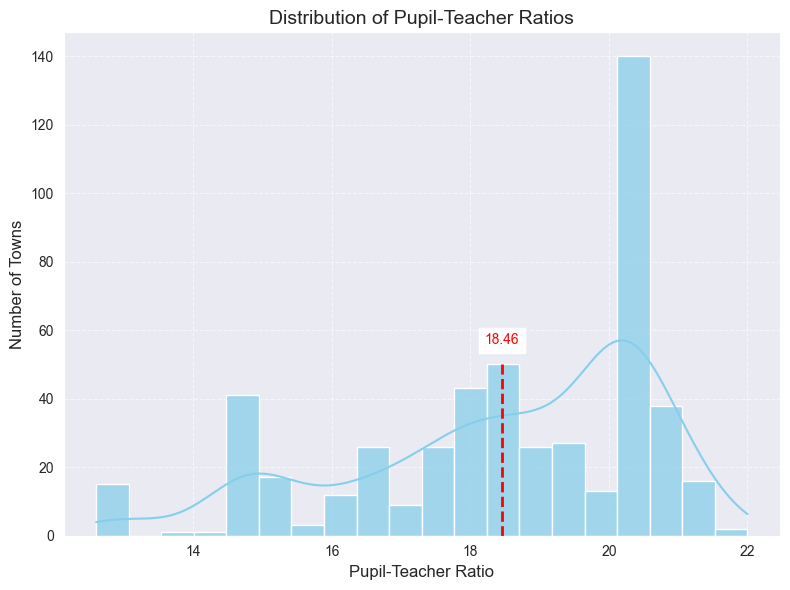

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

mean_ptratio = boston_df['PTRATIO'].mean()

sns.histplot(
    boston_df['PTRATIO'],
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='white',
    alpha=0.75,
    stat='count',
    binrange=(boston_df['PTRATIO'].min(), boston_df['PTRATIO'].max()),
    ax=ax
)

counts, bins = np.histogram(boston_df['PTRATIO'], bins=20, range=(boston_df['PTRATIO'].min(), boston_df['PTRATIO'].max()))

bin_index = np.digitize(mean_ptratio, bins) - 1
bin_height = counts[bin_index]

ax.plot(
    [mean_ptratio, mean_ptratio],
    [0, bin_height],
    color='red',
    linestyle='--',
    linewidth=2,
)

ax.text(
    mean_ptratio,
    bin_height + 5,
    f'{mean_ptratio:.2f}',
    color='red',
    ha='center',
    va='bottom',
    fontsize=10,
    backgroundcolor='white'
)

ax.set_title('Distribution of Pupil-Teacher Ratios', fontsize=14)
ax.set_xlabel('Pupil-Teacher Ratio', fontsize=12)
ax.set_ylabel('Number of Towns', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()